# Predição de Gênero - Análise de Reviews

- **Aluno:** Pedro Yutaro Mont Morency Nakamura  
- **Data:** 17/05/2026
- **Objetivo:** Desenvolver um modelo de classificação para predizer gênero...

## 0. Configurações e Importações de Dependẽncias e Dados

In [142]:
import os
import time
import pickle
import pandas as pd
import numpy as np

# Visualização de Dados
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-Processamento
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import spacy
from tqdm import tqdm
from spacy.matcher import Matcher

# Estruturas e estatística
from scipy.stats import loguniform, randint, uniform, mannwhitneyu

# Classificadores e seleção
from xgboost import XGBClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

# Validação e busca de hiperparâmetros
from sklearn.base import clone, BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline, FeatureUnion

### 0.1 Configuração de Gráficos

In [143]:
# Configurações de visualização
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

### 0.2 Carregamento do modelo SpaCy para Português

In [144]:
try:
    # Carrega apenas componentes necessarios para POS/lemmas.
    disable=["parser", "ner"]
    nlp = spacy.load("pt_core_news_lg", disable=disable)
    print("✅ SpaCy pt_core_news_lg carregado com sucesso!")
except Exception as e:
    print(f"❌ Erro ao carregar o modelo: {e}")

✅ SpaCy pt_core_news_lg carregado com sucesso!


### 0.3 Importação dos Datasets

In [145]:
# Caminhos para os dados
TRAIN_PATH = './data/treino.csv'
VALIDATION_PATH = './data/validacao.csv'

In [146]:
# Carregando CSVs
df_train = pd.read_csv(TRAIN_PATH, encoding='utf-8', low_memory=False)
df_val = pd.read_csv(VALIDATION_PATH, encoding='utf-8', low_memory=False)

## 1. Exploração dos Dados

In [8]:
print(f"Treino: {len(df_train)} reviews")
print(f"Distribuição de gênero:\n{df_train['reviewer_gender'].value_counts()}")
df_train.head()

Treino: 76942 reviews
Distribuição de gênero:
reviewer_gender
M    39699
F    37243
Name: count, dtype: int64


,submission_date,reviewer_id,product_id,product_name,product_brand,site_category_lv1,site_category_lv2,review_title,overall_rating,recommend_to_a_friend,review_text,reviewer_birth_year,reviewer_gender,reviewer_state
0,2018-01-25 15:09:27,a06d0380bcd447431774739131312d3532e1018988da8c...,129610281,"iPhone 7 Plus 128GB dourado Tela Retina HD 5,5...",apple,Celulares e Smartphones,Smartphone,Iphone,3,Yes,É Verdade Mesmo Gente Essa Promocao? To queren...,1994.0,F,BA
1,2018-05-14 16:20:25,62bbbab0822b6917233e8a9846dc3e7acbdfe6b4df788a...,120934895,"TV LED 32"" Sony KDL-32R305B HD com Conversor D...",sony,TV e Home Theater,TV,Marca conceituada,3,Yes,"Acredito ser uma Boa TV, não tenho como ava...",1965.0,M,BA
2,2018-05-19 15:43:40,27908d4eea73f655ca4d50adc1c373efccc3b748d4a779...,15844032,Suporte P/ Notebook C/ Cooler Gamer Warrior - ...,NaN,Informática e Acessórios,Peças para Notebook,Excelente aquisição,5,Yes,A compra do produto confirmou a qualidade de o...,1951.0,M,PE
3,2018-01-14 14:35:10,b1ddb4c179231ffb650097bec1ad8033dc8c2bad60a846...,132444050,Smartphone Motorola Moto G 5S Dual Chip Androi...,NaN,Celulares e Smartphones,Smartphone,Atende as necessidades,4,Yes,Celular intermediário de bom custo benefício. ...,1978.0,F,PA
4,2018-03-08 12:40:03,4188541be9484e0e49c4803e767354c3e84e419a2d23da...,132522724,Panela de Pressão Elétrica Digital Philco Pppv...,NaN,Eletroportáteis,Panela Elétrica,Muito bom,4,Yes,"Prática, fácil de limpar, excelente produto. R...",1980.0,F,RJ


In [9]:
print(f"Validação: {len(df_val)} reviews")
print(f"Distribuição de gênero:\n{df_val['reviewer_gender'].value_counts()}")
df_val.head()

Validação: 25647 reviews
Distribuição de gênero:
reviewer_gender
M    13233
F    12414
Name: count, dtype: int64


,submission_date,reviewer_id,product_id,product_name,product_brand,site_category_lv1,site_category_lv2,review_title,overall_rating,recommend_to_a_friend,review_text,reviewer_birth_year,reviewer_gender,reviewer_state
0,2018-04-30 19:24:28,fabc81c4fa9efa6867a78d82ce2713099ed1eea5df9d80...,31575567,Vela Led Decorativa 15cm Pilha Amarelo-Der/07-...,NaN,Decoração,Luminária,Efeito bonito,4,Yes,Gostei do efeito. Parece uma vela de verdade. ...,1954.0,F,RS
1,2018-04-27 17:48:48,6fbac43a75fd2dbb7e74687472779b74cc9602a566be74...,132474081,Smartphone Moto G 5S Dual Chip Android 7.0 Tel...,NaN,Celulares e Smartphones,Smartphone,"Hardware fraco, mas conjunto excelente.",4,Yes,Não me arrependo de ter comprado o G5S à conco...,1996.0,M,RJ
2,2018-03-06 18:45:17,e85bcc86d48fdd1462bada4d5f4f19cde9f86acf157992...,16215756,Cadeira Amanda Medalhao Marrom Rivatti,NaN,Móveis,Cadeira,Excelente qualidade,5,Yes,"Produto recebido dentro do prazo, acondicionad...",1973.0,F,SP
3,2018-05-18 07:00:58,5e054a67eb8f4ab98b0e53c532843f65a49ed17aef8214...,12298660,Kit 2 peças Holofote Refletor Super Led Duplo ...,NaN,Casa e Construção,Iluminação,Produto de Ótima qualidade,4,Yes,"Produto de Ótima qualidade, atendeu todas as m...",1969.0,M,SP
4,2018-04-21 06:31:51,9b22f24daed6d47b570be15dc928f8d522e8e1315f7d0c...,132537782,Smartphone Samsung Galaxy J7 Pro Android 7.0 T...,NaN,Celulares e Smartphones,Smartphone,Satisfeito,5,Yes,"Muito bom aparelho. Fotos e vídeos perfeitos, ...",1973.0,M,SP


### 3.1 Contagem de valores e tipos

In [8]:
print('\n<===== TRAIN DATAFRAME =====>')
df_train.info()


<===== TRAIN DATAFRAME =====>
<class 'pandas.DataFrame'>
RangeIndex: 76942 entries, 0 to 76941
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   submission_date        76942 non-null  str    
 1   reviewer_id            76942 non-null  str    
 2   product_id             76942 non-null  str    
 3   product_name           76903 non-null  str    
 4   product_brand          24162 non-null  str    
 5   site_category_lv1      76942 non-null  str    
 6   site_category_lv2      74687 non-null  str    
 7   review_title           76776 non-null  str    
 8   overall_rating         76942 non-null  int64  
 9   recommend_to_a_friend  76932 non-null  str    
 10  review_text            75056 non-null  str    
 11  reviewer_birth_year    75753 non-null  float64
 12  reviewer_gender        76942 non-null  str    
 13  reviewer_state         76942 non-null  str    
dtypes: float64(1), int64(1), str(12)
m

In [10]:
print('\n<===== VALIDATION DATAFRAME =====>')
df_val.info()


<===== VALIDATION DATAFRAME =====>
<class 'pandas.DataFrame'>
RangeIndex: 25647 entries, 0 to 25646
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   submission_date        25647 non-null  str    
 1   reviewer_id            25647 non-null  str    
 2   product_id             25647 non-null  int64  
 3   product_name           25629 non-null  str    
 4   product_brand          8048 non-null   str    
 5   site_category_lv1      25645 non-null  str    
 6   site_category_lv2      24875 non-null  str    
 7   review_title           25598 non-null  str    
 8   overall_rating         25647 non-null  int64  
 9   recommend_to_a_friend  25646 non-null  str    
 10  review_text            25044 non-null  str    
 11  reviewer_birth_year    25242 non-null  float64
 12  reviewer_gender        25647 non-null  str    
 13  reviewer_state         25647 non-null  str    
dtypes: float64(1), int64(2), str(

#### Verificando Valores Nulos

In [10]:
df_train.isna().sum()

submission_date              0
reviewer_id                  0
product_id                   0
product_name                39
product_brand            52780
site_category_lv1            0
site_category_lv2         2255
review_title               166
overall_rating               0
recommend_to_a_friend       10
review_text               1886
reviewer_birth_year       1189
reviewer_gender              0
reviewer_state               0
dtype: int64

In [11]:
df_val.isna().sum()

submission_date              0
reviewer_id                  0
product_id                   0
product_name                18
product_brand            17599
site_category_lv1            2
site_category_lv2          772
review_title                49
overall_rating               0
recommend_to_a_friend        1
review_text                603
reviewer_birth_year        405
reviewer_gender              0
reviewer_state               0
dtype: int64

Commo é possível observar, em ambos os datasets há presença de valores nulos referente ao texto. Registros sem conteúdo textual devem ser removidos.

#### Perguntas Norteadoras:
- Q1: A marca do produto (mesmo senddo apeans 32%), possui alguma correlação com o gênero do reviwer?
- Q2: Gênero vs. Categorias (site_category_lv1): Existem categorias de produtos onde um gênero comenta mais que o outro? (Ex: Maquiagem vs. Ferramentas)
- Q3: Gênero vs. Avaliação (overall_rating): Homens ou mulheres tendem a ser mais críticos ou elogiosos nas estrelas?.
- Q4: Existe uma diferença estatisticamente relevante no tamanho das mensagens escritas por homens e mulheres?.

#### Filtro inicial: remover reviews sem texto para não enviesar a análise de tamanho


Antes de analisar, precisamos tratar os nulos no texto e criar a métrica de tamanho de mensagem.

In [147]:
df_train_eda = df_train.dropna(subset=['review_text']).copy()

#### Criando métricas de texto

In [148]:
df_train_eda['text_len'] = df_train_eda['review_text'].str.len()
# count words in title + review text
df_train_eda['word_count'] = (
    df_train_eda['review_title'].fillna('').astype(str) + ' ' +
    df_train_eda['review_text'].fillna('').astype(str)
).str.count(r'\w+').astype(int)

print(df_train_eda['word_count'].describe())

count    75056.000000
mean        26.137218
std         22.835308
min          0.000000
25%         13.000000
50%         19.000000
75%         30.000000
max        802.000000
Name: word_count, dtype: float64


### Q1: A marca do produto possui correlação com o gênero?

OBS: Mesmo com apenas 32% de preenchimento, as marcas podem indicar nichos específicos.

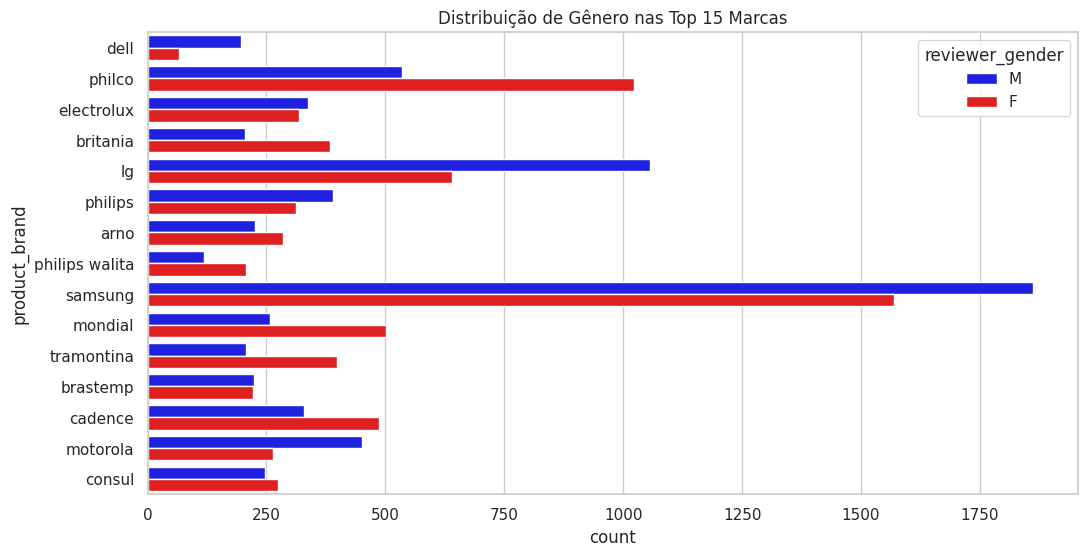

In [149]:
# Analisando as N marcas mais frequentes (onde não é nulo)
N_BRANDS = 15
top_brands = df_train_eda['product_brand'].value_counts().nlargest(N_BRANDS).index
df_brands = df_train_eda[df_train_eda['product_brand'].isin(top_brands)]

plt.figure(figsize=(12, 6))
sns.countplot(data=df_brands, y='product_brand', hue='reviewer_gender', palette=['blue', 'red'])
plt.title(f'Distribuição de Gênero nas Top {N_BRANDS} Marcas')
plt.show()

### Q2: Gênero vs. Categorias

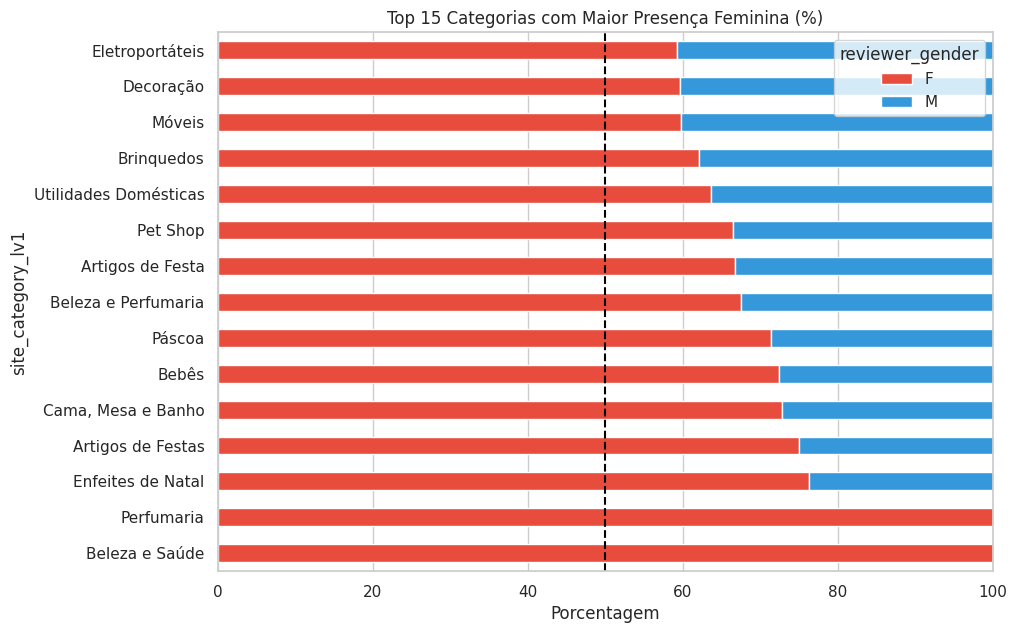

In [150]:
# Proporção de gênero por categoria
cat_gender_dist = pd.crosstab(df_train_eda['site_category_lv1'], df_train_eda['reviewer_gender'], normalize='index') * 100
cat_gender_dist = cat_gender_dist.sort_values(by='F', ascending=False).head(15)

cat_gender_dist.plot(kind='barh', stacked=True, figsize=(10, 7), color=['#e74c3c', '#3498db'])
plt.title('Top 15 Categorias com Maior Presença Feminina (%)')
plt.xlabel('Porcentagem')
plt.axvline(50, color='black', linestyle='--') # Linha de equilíbrio
plt.show()

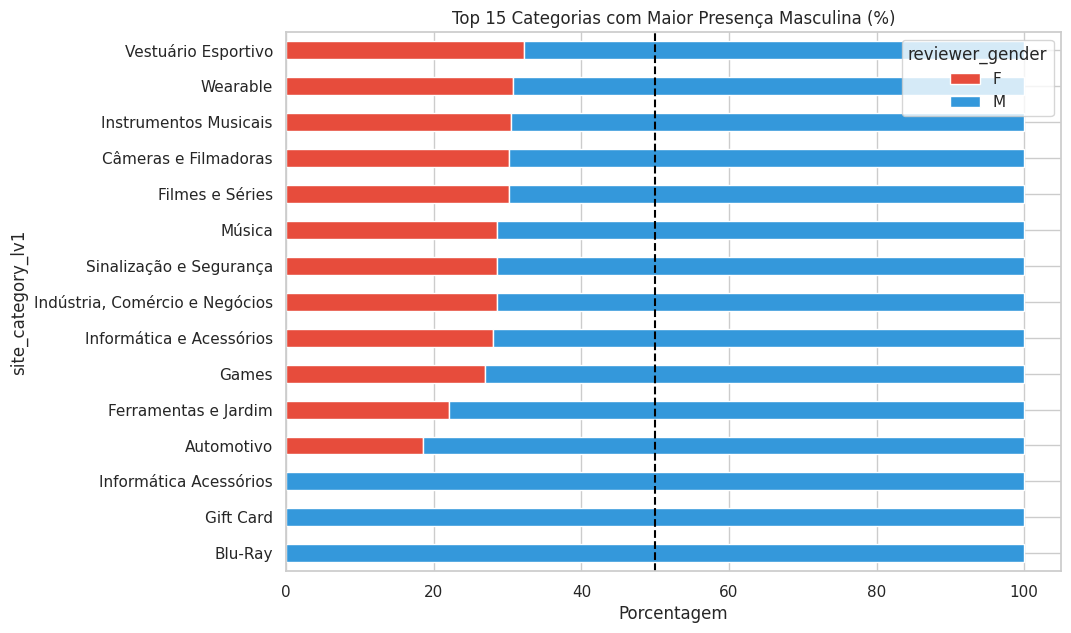

In [10]:
# Proporção de gênero por categoria
cat_gender_dist = pd.crosstab(df_train_eda['site_category_lv1'], df_train_eda['reviewer_gender'], normalize='index') * 100
cat_gender_dist = cat_gender_dist.sort_values(by='M', ascending=False).head(15)

cat_gender_dist.plot(kind='barh', stacked=True, figsize=(10, 7), color=['#e74c3c', '#3498db'])
plt.title('Top 15 Categorias com Maior Presença Masculina (%)')
plt.xlabel('Porcentagem')
plt.axvline(50, color='black', linestyle='--') # Linha de equilíbrio
plt.show()

### Q3: Gênero vs. Avaliação

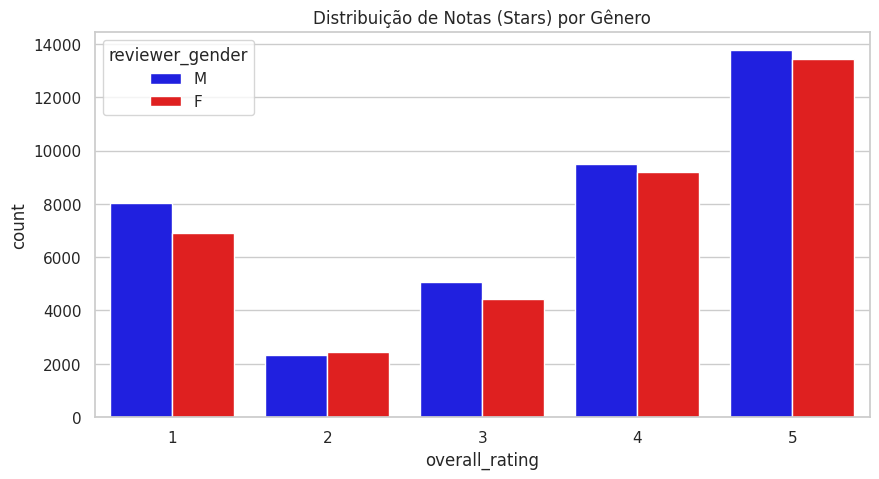

reviewer_gender
F    3.543199
M    3.482827
Name: overall_rating, dtype: float64


In [11]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df_train_eda, x='overall_rating', hue='reviewer_gender', palette=['blue', 'red'])
plt.title('Distribuição de Notas (Stars) por Gênero')
plt.show()

# Médias exatas
print(df_train_eda.groupby('reviewer_gender')['overall_rating'].mean())

### Q4: Diferença estatística no tamanho das mensagens

Usando Mann-Whitney U (pois o tamanho de texto raramente segue uma distribuição normal).

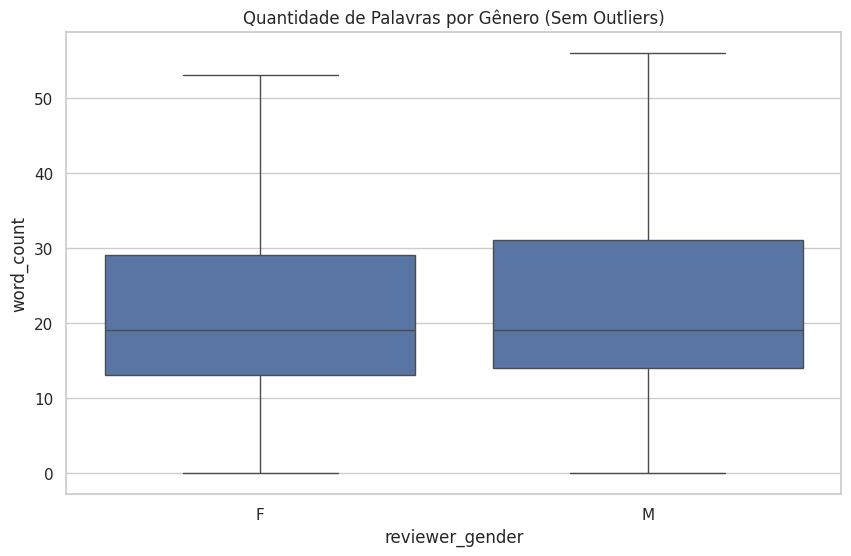

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_train_eda, x='reviewer_gender', y='word_count', showfliers=False)
plt.title('Quantidade de Palavras por Gênero (Sem Outliers)')
plt.show()

In [151]:
# Teste estatístico
males = df_train_eda[df_train_eda['reviewer_gender'] == 'M']['word_count']
females = df_train_eda[df_train_eda['reviewer_gender'] == 'F']['word_count']
stat, p = mannwhitneyu(males, females)

print(f"Mediana Masculina: {males.median()} | Mediana Feminina: {females.median()}")
print(f"P-valor do teste Mann-Whitney: {p}")

Mediana Masculina: 19.0 | Mediana Feminina: 19.0
P-valor do teste Mann-Whitney: 9.49215400150229e-10


## Conclusões Preliminares:
1. Q1: A marca do produto possui correlação com o gênero? Sim, aparentemente, há uma correlação.
2. Q2: Apresenta uma forte correlação
3. Q3: Não apresenta correlação
4. Q4: Como p < 0.5, posso dizer que sim, há uma diferença estatisticamente relevante entre a distribuição de wordcount por gênero

#### Outras Perguntas:
- Q5: Existe um gênero que tende a recomendar o produto mesmo dando notas baixas (3 ou 4)?
- Q6: O uso de múltiplas exclamações (ex: "Amei!!!") ou letras repetidas ("Linnnnndo") ou emojis é mais frequente em qual gênero?
- Q7: Há variação no volume de reviews entre janeiro e maio de 2018 para cada gênero? (ex: dia das mães, dia das mulheres ou dia dos pais).
- Q8: Como a idade (reviewer_birth_year) se distribui entre os gêneros?.

### Q5:

In [152]:
# Filtramos apenas as notas 3 e 4 (a "zona cinzenta" mencionada no artigo)
df_mid_ratings = df_train_eda[df_train_eda['overall_rating'].isin([3, 4])].copy()

# Calculamos a proporção
q5_crosstab = pd.crosstab(df_mid_ratings['reviewer_gender'], df_mid_ratings['recommend_to_a_friend'], normalize='index') * 100

print(q5_crosstab)

recommend_to_a_friend        No        Yes
reviewer_gender                           
F                      4.441671  95.558329
M                      5.147210  94.852790


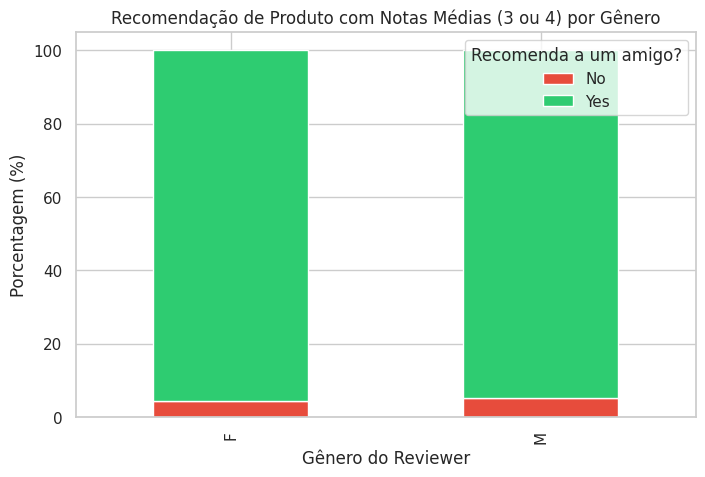

In [16]:
q5_crosstab.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#e74c3c', '#2ecc71'])
plt.title('Recomendação de Produto com Notas Médias (3 ou 4) por Gênero')
plt.ylabel('Porcentagem (%)')
plt.xlabel('Gênero do Reviewer')
plt.legend(title='Recomenda a um amigo?', loc='upper right')
plt.show()

### Q6: Uso de caracteres repetidos e pontuação excessiva (Análise Estilométrica)

In [153]:
# 1. Múltiplas pontuações seguidas (ex: !!!, ???, ..)
cspam = r'[!?\.]{2,}'
df_train_eda['multi_punct'] = df_train_eda['review_text'].str.contains(cspam, regex=True, na=False)

# 2. Letras repetidas 3 vezes ou mais (ex: ameeei, lindooo)
df_train_eda['repeated_letters'] = df_train_eda['review_text'].str.contains(r'([a-zA-Z])\1{2,}', regex=True, na=False)

# Agrupa e calcula a porcentagem de reviews que contêm esses padrões
style_analysis = df_train_eda.groupby('reviewer_gender')[['multi_punct', 'repeated_letters']].mean() * 100

print("Porcentagem de uso de estilos textuais:")
print(style_analysis)

/tmp/ipykernel_558334/2711003068.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_train_eda['repeated_letters'] = df_train_eda['review_text'].str.contains(r'([a-zA-Z])\1{2,}', regex=True, na=False)


Porcentagem de uso de estilos textuais:
                 multi_punct  repeated_letters
reviewer_gender                               
F                  17.414125          1.791701
M                  15.212331          1.414680


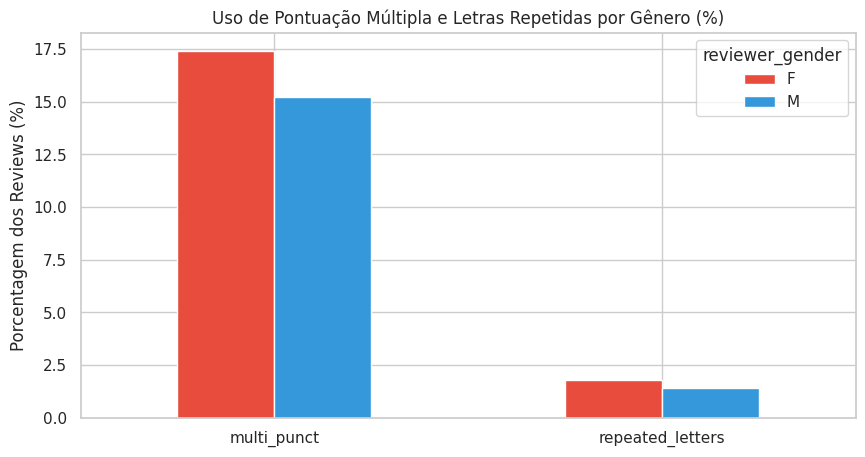

In [18]:
style_analysis.T.plot(kind='bar', figsize=(10, 5), color=['#e74c3c', '#3498db'])
plt.title('Uso de Pontuação Múltipla e Letras Repetidas por Gênero (%)')
plt.ylabel('Porcentagem dos Reviews (%)')
plt.xticks(rotation=0)
plt.show()

### Q6.1 Contagem de caracteres em caixa alta por gênero

In [19]:
df_train_eda['upper'] = df_train_eda['review_text'].str.count(r'\b[A-ZÀ-Ú]{2,}\b').values.astype(np.int32)
upper_analysis = df_train_eda.groupby('reviewer_gender')[['multi_punct', 'repeated_letters', 'upper']].mean() * 100
print(upper_analysis)

                 multi_punct  repeated_letters      upper
reviewer_gender                                          
F                  17.414125          1.791701  61.134927
M                  15.212331          1.414680  88.718771


In [20]:
up = (
    df_train_eda
    .groupby('reviewer_gender', group_keys=False)
    .apply(lambda g: g.nlargest(28, 'upper'))
    [['upper', 'review_text']]
    .reset_index(drop=True)
)
# up

### Q7: Variação no volume de reviews ao longo do tempo

In [21]:
# Converte a coluna para datetime
df_train_eda['date'] = pd.to_datetime(df_train_eda['submission_date'])

# Agrupa por semana para o gráfico não ficar muito ruidoso
df_train_eda['week'] = df_train_eda['date'].dt.to_period('W').apply(lambda r: r.start_time)

# Conta os reviews por semana e por gênero
timeline = df_train_eda.groupby(['week', 'reviewer_gender']).size().reset_index(name='count')

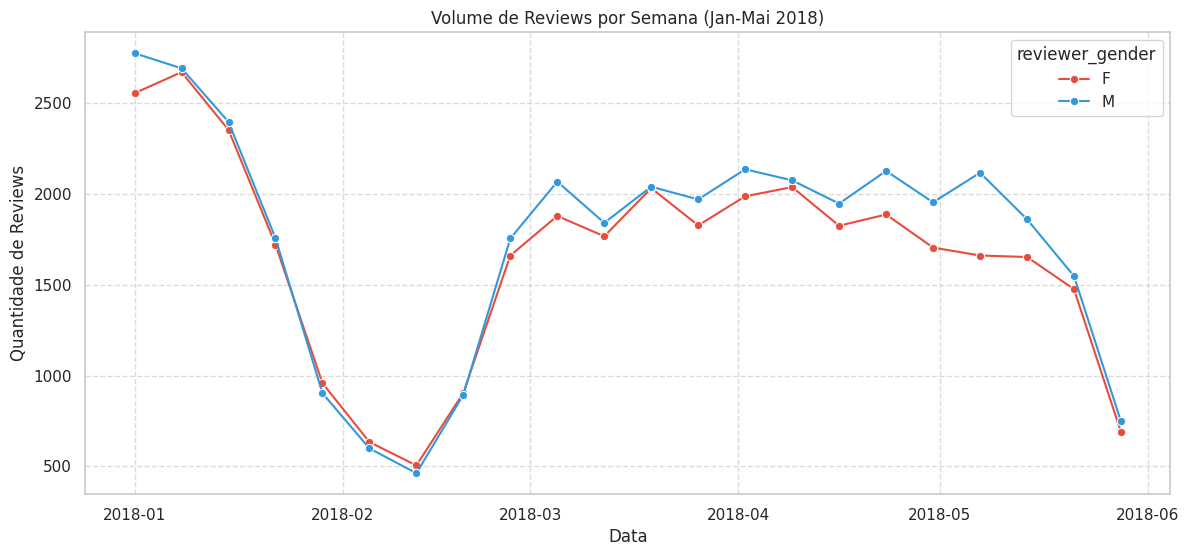

In [22]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=timeline, x='week', y='count', hue='reviewer_gender', palette=['#e74c3c', '#3498db'], marker='o')
plt.title('Volume de Reviews por Semana (Jan-Mai 2018)')
plt.ylabel('Quantidade de Reviews')
plt.xlabel('Data')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Q8: Distribuição de Idade por Gênero

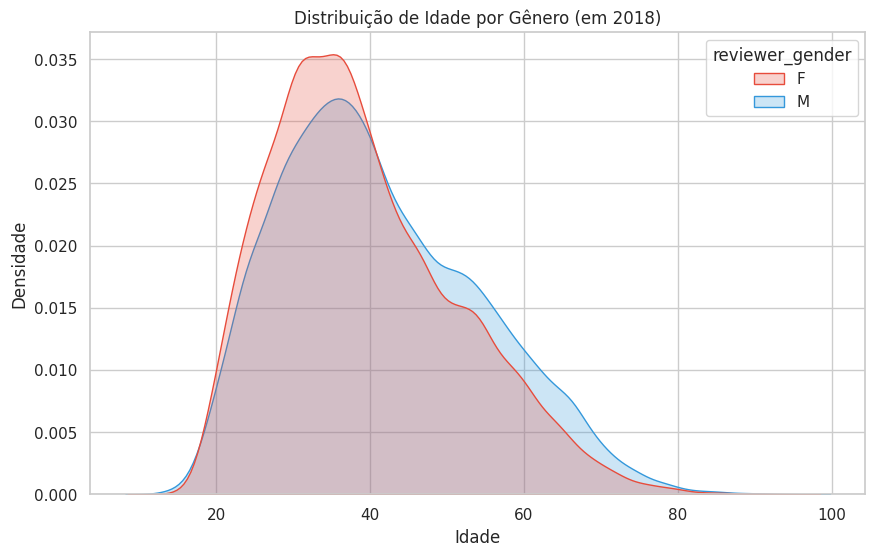

                   count       mean        std   min   25%   50%   75%   max
reviewer_gender                                                             
F                35799.0  39.138942  12.163478  13.0  30.0  37.0  47.0  94.0
M                38029.0  41.314786  13.113703  13.0  31.0  39.0  50.0  95.0


In [154]:
# Filtra anos de nascimento razoáveis (entre 1920 e 2005)
df_age = df_train_eda[(df_train_eda['reviewer_birth_year'] > 1920) & (df_train_eda['reviewer_birth_year'] <= 2005)].copy()

# Calcula a idade em 2018
df_age['age'] = 2018 - df_age['reviewer_birth_year']

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_age, x='age', hue='reviewer_gender', fill=True, common_norm=False, palette=['#e74c3c', '#3498db'])
plt.title('Distribuição de Idade por Gênero (em 2018)')
plt.xlabel('Idade')
plt.ylabel('Densidade')
plt.show()

print(df_age.groupby('reviewer_gender')['age'].describe())

### Resultados Q[5-8]:
- Q5: A diferença entre homens e mulheres ao recomendar um produto com nota média é ínfima (94,8% vs 95,5%) => Ambos tendem a recomendar. coluna recommend_to_a_friend pode ser descartada.
- Q6: Mulheres usam múltiplas pontuações (17,4% vs 15,2%) e letras repetidas (1,7% vs 1,4%) com um pouco mais de frequência. => Exige etapa de pre-processamento.
- Q7: A ausência de picos anômalos ou inversões de proporção entre os meses indica que o comportamento temporal é estável. => A coluna submission_date pode ser descartada.
- Q8: Os homens no dataset são, em média, 2 anos mais velhos que as mulheres (mediana de 39 vs 37). => A coluna reviewer_birth_year é um atributo secundário válido.

### Perguntas associadas a Heurística do Artigo - Módulos de dicionários:
- Q9: Quais são os termos mais discriminativos (Dicionário Latente) por gênero? => Construir diciońario
- Q10: Existe diferença na distribuição do volume de Classes Gramaticais (POS Tags)? (O artigo buscou a flexão do adjetivo.)

### Q9:

A melhor forma de fazer isso sem ter o viéz de remoção de stopwords ou contagem de palavras brutas é aplicando **Log Odds Ratio com Laplace Smoothing (Suavização de Laplace)**.

Essa métrica calcula a probabilidade de uma palavra aparecer em textos femininos versus masculinos.

Valores altos indicam termos fortemente femininos, e valores negativos indicam termos fortemente masculinos.

In [155]:
# 1. Download de stopwords (certifique-se de que o ambiente uv tem o nltk instalado)
nltk.download('stopwords', quiet=True)
stop_words_pt = stopwords.words('portuguese')

In [156]:
# Adicionando algumas stopwords específicas de e-commerce que não ajudam na discriminação
stop_words_pt.extend(['produto', 'comprei', 'veio', 'chegou', 'dia', 'loja', 'americanas', 'pra'])

Função de limpeza EXCLUSIVA para a Q9

In [157]:
# (Não use no pipeline final!)
def clean_for_eda(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    # Mantém apenas letras (incluindo acentuadas) e espaços
    text = re.sub(r'[^a-zãõáéíóúâêîôûàèìòùç\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

Trabalhando em uma cópia segura para não alterar o df original

In [158]:
df_q9 = df_train_eda[['review_text', 'reviewer_gender']].dropna().copy()
df_q9['clean_text'] = df_q9['review_text'].apply(clean_for_eda)

In [159]:
# 3. Vetorização (Contagem pura de frequência)
# min_df=20 ignora palavras raras que apareceram em menos de 20 reviews
MIN_DF=20
vec = CountVectorizer(stop_words=stop_words_pt, min_df=MIN_DF, ngram_range=(1, 2))
X = vec.fit_transform(df_q9['clean_text'])
words = vec.get_feature_names_out()

In [160]:
# Separar as matrizes de contagem por gênero
mask_F = (df_q9['reviewer_gender'] == 'F').values
mask_M = (df_q9['reviewer_gender'] == 'M').values

In [161]:
# 4. Somar frequências aplicando Laplace Smoothing (+1) para evitar divisão por zero
word_counts_F = np.asarray(X[mask_F].sum(axis=0)).flatten() + 1
word_counts_M = np.asarray(X[mask_M].sum(axis=0)).flatten() + 1

In [162]:
# Frequência relativa (normalizada pelo volume total de palavras do gênero)
total_F = word_counts_F.sum()
total_M = word_counts_M.sum()

In [163]:
freq_rel_F = word_counts_F / total_F
freq_rel_M = word_counts_M / total_M

In [164]:
# 5. Calcular o Log Odds Ratio
# > 0 (viés Feminino), < 0 (viés Masculino)
log_odds = np.log(freq_rel_F / freq_rel_M)

In [165]:
# Criar DataFrame consolidado
df_words = pd.DataFrame({
    'palavra': words,
    'log_odds': log_odds,
    'count_F': word_counts_F - 1, # removendo o smoothing para visualização real
    'count_M': word_counts_M - 1
})

In [166]:
# Filtro de relevância: analisar apenas palavras com mais de 100 aparições totais
MIN_OCC = 500
df_words = df_words[(df_words['count_F'] + df_words['count_M']) > MIN_OCC]

In [167]:
# Pegar as Top N de cada lado
TOP = 50
top_fem = df_words.nlargest(TOP, 'log_odds')
top_masc = df_words.nsmallest(TOP, 'log_odds').copy()
top_masc['log_odds_abs'] = abs(top_masc['log_odds']) # Valor absoluto para o gráfico

/tmp/ipykernel_558334/3886855945.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_fem, x='log_odds', y='palavra', palette='Reds_r')
/tmp/ipykernel_558334/3886855945.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_masc, x='log_odds_abs', y='palavra', palette='Blues_r')


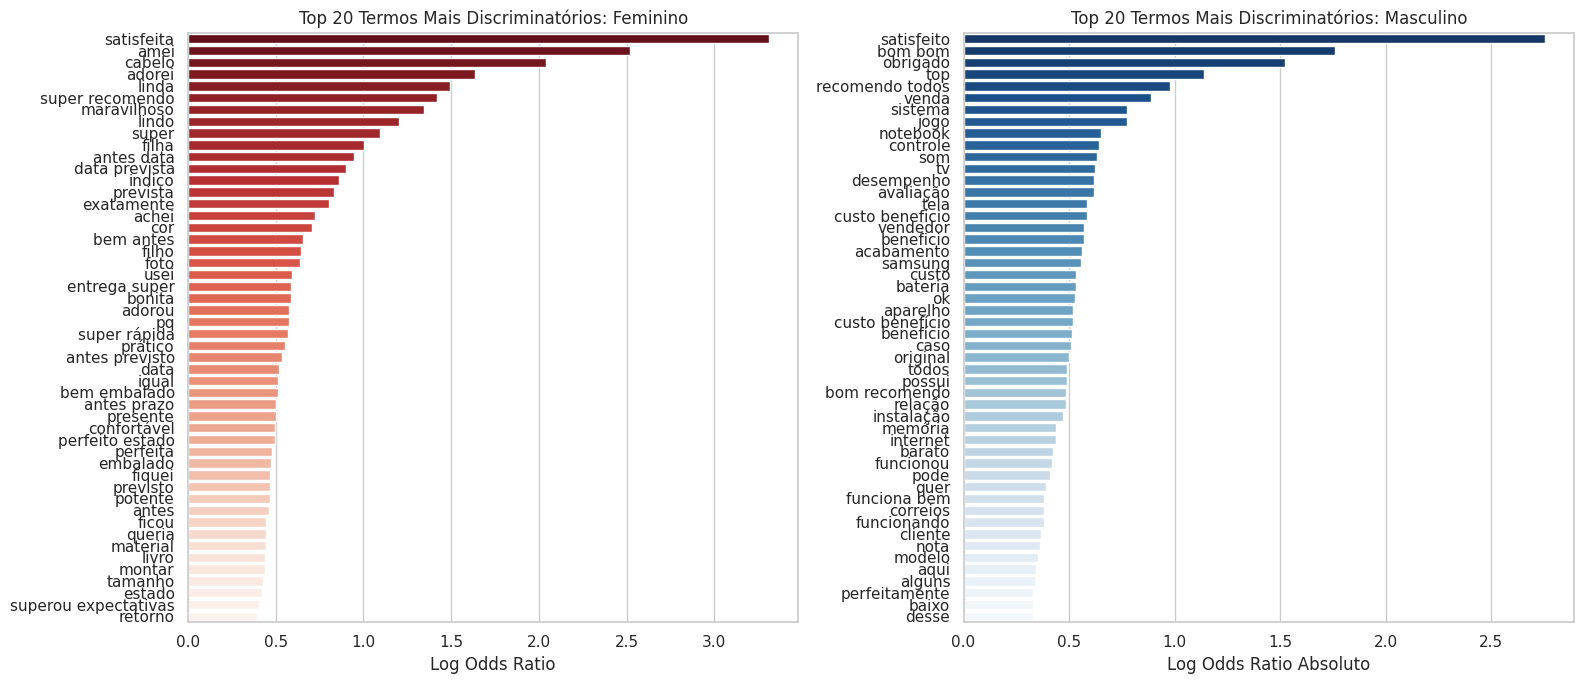

In [168]:
# 6. Visualização
plt.figure(figsize=(16, 7))

# Gráfico Feminino
plt.subplot(1, 2, 1)
sns.barplot(data=top_fem, x='log_odds', y='palavra', palette='Reds_r')
plt.title('Top 20 Termos Mais Discriminatórios: Feminino')
plt.xlabel('Log Odds Ratio')
plt.ylabel('')

# Gráfico Masculino
plt.subplot(1, 2, 2)
sns.barplot(data=top_masc, x='log_odds_abs', y='palavra', palette='Blues_r')
plt.title('Top 20 Termos Mais Discriminatórios: Masculino')
plt.xlabel('Log Odds Ratio Absoluto')
plt.ylabel('')

plt.tight_layout()
plt.show()

In [71]:
print(top_masc.nlargest(28, 'log_odds'))

           palavra  log_odds  count_F  count_M  log_odds_abs
2333         metal -1.027596       26       83      1.027596
488           bola -1.073467       34      113      1.073467
1661         filme -1.087243       42      141      1.087243
514         botões -1.096589       35      119      1.096589
1811        gastar -1.096589       26       89      1.096589
3415          show -1.101577       79      267      1.101577
3635           top -1.117912      115      394      1.117912
217         antena -1.124760       27       95      1.124760
3012           pré -1.131681       41      144      1.131681
2668            pc -1.168910       35      128      1.168910
2392         mouse -1.178267       46      169      1.178267
1818            gb -1.228900       81      311      1.228900
3909       windows -1.236351       35      137      1.236351
1574         faixa -1.247162       23       92      1.247162
2727   performance -1.329683       23      100      1.329683
680          chave -1.33

In [72]:
print(top_fem.nlargest(28, 'log_odds'))

           palavra  log_odds  count_F  count_M
2013  insatisfeita  3.389234      212        7
3346    satisfeita  3.333293     1283       50
677       chateada  3.216444      111        4
2520      obrigada  3.145391      458       21
1041  decepcionada  2.938416      457       26
186           amei  2.536818     1384      121
173         amando  2.366166      133       13
547         cabelo  2.060630      683       96
548        cabelos  2.035826      226       32
196            amo  1.974650      109       16
764       comentar  1.801979       97       17
1421        escova  1.799770      200       36
2866       prancha  1.785030       90       16
499         boneca  1.716821      179       35
198           amou  1.678773      360       74
90          adorei  1.653517     1468      312
2176        lindas  1.650130      144       30
3354          seca  1.619972      117       25
3355       secador  1.619366      126       27
1116        desejo  1.611461       98       21
91           

#### Conclusão preliminar do Q9:
- As pessoas utilizam a primeira pessoa do singular e flexionam o adjetivo/particípio para o seu próprio gênero na hora de avaliar.
- A categoria do produto (validado na Q2) reflete diretamente no vocabulário usado no texto.

### Q10: : A proporção de uso de certas classes gramaticais varia por gênero?

Como os homens citaram muitas **especificações técnicas (RAM, HD, PC)** e as mulheres focaram em **percepções e ações (Amei, Adorei, Maravilhosa)**:

H: Homens usam mais Substantivos (NOUN) e Nomes Próprios (PROPN), enquanto mulheres usam mais Verbos (VERB) e Adjetivos (ADJ).

In [169]:
def extract_pos_counts(texts):
    pos_counts = []
    # nlp.pipe processa em lotes, o que é muito mais rápido
    for doc in tqdm(nlp.pipe(texts, batch_size=500), total=len(texts)):
        counts = {'NOUN': 0, 'ADJ': 0, 'VERB': 0, 'PROPN': 0}
        for token in doc:
            if token.pos_ in counts:
                counts[token.pos_] += 1
                
        # Normalização: calcular a proporção em relação ao tamanho do texto
        # Adiciona +1 no denominador para evitar divisão por zero em textos vazios
        total_tokens = len(doc) + 1
        pos_counts.append({
            'noun_ratio': counts['NOUN'] / total_tokens,
            'adj_ratio': counts['ADJ'] / total_tokens,
            'verb_ratio': counts['VERB'] / total_tokens,
            'propn_ratio': counts['PROPN'] / total_tokens
        })
    return pd.DataFrame(pos_counts)

In [39]:
txt = df_train_eda['review_text'].fillna("")
df_pos_train = extract_pos_counts(txt)
df_train_eda = pd.concat([df_train_eda.reset_index(drop=True), df_pos_train], axis=1)

100%|███████████████████████████████████████████████| 75056/75056 [01:09<00:00, 1075.41it/s]


In [61]:
counts = ['noun_ratio', 'adj_ratio', 'verb_ratio', 'propn_ratio']
res = df_train_eda.groupby('reviewer_gender')[counts]
print(res.mean())

                 noun_ratio  adj_ratio  verb_ratio  propn_ratio
reviewer_gender                                                
F                  0.181952   0.081523    0.135047     0.026356
M                  0.189385   0.079216    0.126402     0.033493


#### Análise dos Resultados de Q10:
- Masculino (noun_ratio e propn_ratio maiores): Foco em objetos, entidades e especificações técnicas (Nomes Próprios e Substantivos). Eles avaliam o que o produto é.
- Feminino (adj_ratio e verb_ratio maiores): Foco em qualidades, percepções e ações (Adjetivos e Verbos). Elas avaliam como se sentiram com o produto ou o serviço.

H: VERDADEIRA!

### Conclusões das Análises "Q":
As features mais relevantes para inferir o gênero são:
- A Categoria do Produto (site_category_lv1): A separação de interesse é nítida (ex: Beleza vs. Hardware).
- O Texto Limpo (com Flexões): TF-IDF do texto, mantendo a gramática que indica gênero ("obrigada" vs "obrigado").
- Features de POS-TAG: Relação de Adjetivos, Verbos, Substantivos e Nomes Próprios.
- Estilometria (Q6): Contagem de múltiplas pontuações (!!!), uppercase e letras repetidas (ameeei).
- Idade (reviewer_birth_year): Feature de apoio.
- Tamanho do texto

# 3. Pré-Processamento

Como será necessário orquestrar simultâneamente:
- O texto puro
- A extração de classes gramaticais (POS)
- A estilometria
- Os metadados categóricos de forma

A melhor abordagem é construir Transformadores Customizados que se integram nativamente ao ecossistema do Scikit-Learn

### Plano de Estruturação do Pipeline:
O pipeline será dividido em 3 branches que processam diferentes aspectos do dado bruto em paralelo, unindo os resultados no final para alimentar o classificador:

- B1: **Processamento de Texto (NLP Semântico)**: Limpa o texto preservando flexões de gênero (sem stemming), injeta tokens de estilometria (__multipunct__) e aplica o TfidfVectorizer (N-gramas 1 e 2).

- B2: **Engenharia de Features (Sintaxe e Estilometria)**: Extrai e calcula as proporções de Caixa Alta (Q6.1), repetições (Q6) e as classes gramaticais via spaCy (Q10). Preenche nulos e normaliza a escala (StandardScaler).

- B3: **Metadados Estruturados**: Preenche valores nulos (mediana para idade, "Desconhecido" para categoria), normaliza a idade e aplica OneHotEncoder na categoria.

### Implementação dos Transformadores Customizados

Classes de Transformadores que o Scikit-Learn usará para transformar os dados brutos nos bastidores.

In [172]:
class TextCleaner(BaseEstimator, TransformerMixin):
    """Transformador para limpar o texto sem destruir flexões de gênero."""
    
    def fit(self, X, y=None):
        return self
        
    def transform(self, X, y=None):
        # X é esperado como uma pd.Series (a coluna review_text)
        cleaned_texts = []
        texts = X.fillna("").astype(str).tolist()
        
        for text in texts:
            if not isinstance(text, str):
                cleaned_texts.append("")
                continue
                
            t = text.lower()
            
            # 1. REMOÇÃO DE RUÍDOS WEB (URLs e Menções)
            # Remove links http/https e www.
            t = re.sub(r'http\S+|www\.\S+', ' ', t)
            # Remove menções estilo Twitter/Instagram (@usuario)
            t = re.sub(r'@\w+', ' ', t)

            # 2. PRESERVAÇÃO DE ESTILOMETRIA
            # Converte pontuações múltiplas e letras repetidas em tokens antes de limpar a pontuação
            t = re.sub(r'[!?\.]{2,}', ' __multipunct__ ', t)
            t = re.sub(r'([a-z])\1{2,}', r'\1 __repeatletter__ ', t)

            # 3. LIMPEZA FINAL
            # Remove números e pontuações, mantendo apenas letras (acentuadas) e nossos tokens '_'
            t = re.sub(r'[^a-zãõáéíóúâêîôûàèìòùç\s_]', ' ', t)
            
            # Remove espaços múltiplos resultantes das substituições
            t = re.sub(r'\s+', ' ', t).strip()
            cleaned_texts.append(t)
            
        return cleaned_texts

In [124]:
class FeatureExtractor(BaseEstimator, TransformerMixin):
    """Transformador para extrair estatísticas de POS Tagging e Estilometria."""
    
    def fit(self, X, y=None):
        return self
        
    def transform(self, X, y=None):
        # X é esperado como uma pd.Series (a coluna review_text bruta)
        features = []
        texts = X.fillna("").astype(str).tolist()
        # O nlp.pipe garante processamento rápido em lote
        for doc in nlp.pipe(texts, batch_size=500):
            text_str = doc.text
            total_tokens = len(doc) + 1 # +1 evita divisão por zero
            
            # 1. Contagens do spaCy (Q10)
            counts = {'NOUN': 0, 'ADJ': 0, 'VERB': 0, 'PROPN': 0}
            for token in doc:
                if token.pos_ in counts:
                    counts[token.pos_] += 1
            
            # 2. Estilometria (Q6 e Q6.1)
            upper_count = len(re.findall(r'\b[A-ZÀ-Ú]{2,}\b', text_str))
            multipunct_count = len(re.findall(r'[!?\.]{2,}', text_str))
            word_count = len([t for t in doc if not t.is_punct])
            
            # Calcula proporções
            features.append({
                'noun_ratio': counts['NOUN'] / total_tokens,
                'adj_ratio': counts['ADJ'] / total_tokens,
                'verb_ratio': counts['VERB'] / total_tokens,
                'propn_ratio': counts['PROPN'] / total_tokens,
                'upper_ratio': upper_count / total_tokens,
                'multipunct_ratio': multipunct_count / total_tokens,
                'word_ratio': word_count 
            })
            
        return pd.DataFrame(features)

## Montagem do Pipeline Principal

Conectando os transformadores em um único objeto de pré-processamento. Este será usado para o treino e validação em cima dos dados brutos.

Stopwords ajustadas (removendo as que bloqueiam a identificação de gênero):

In [173]:
stop_words_pt = nltk.corpus.stopwords.words('portuguese')
stop_words_pt = [w for w in stop_words_pt if w not in ['meu', 'minha', 'teu', 'tua', 'nosso', 'nossa']]

## ETAPA PRÉ-PIPELINE: Combinando as Features de Texto

Combinando título e texto para não perder nenhuma informação semântica
e Texto

In [174]:
df_train['full_text'] = df_train['review_title'].fillna("") + " " + df_train['review_text'].fillna("")
df_val['full_text'] = df_val['review_title'].fillna("") + " " + df_val['review_text'].fillna("")

Selecionando as features corrigidas


In [175]:
X_train = df_train[['full_text', 'reviewer_birth_year', 'site_category_lv1', 'site_category_lv2']]
y_train = df_train['reviewer_gender']

In [176]:
X_val = df_val[['full_text', 'reviewer_birth_year', 'site_category_lv1', 'site_category_lv2']]
y_val = df_val['reviewer_gender']

# 4. Representação Textual

## Fase 1: Otimização Extrema do TF-IDF

- **N-gramas de Palavras vs. N-gramas de Caracteres**
- **Ajuste do max_features e min_df**

#### Objetivo: extrair o máximo de sinal possível do texto usando o TfidfVectorizer.

Na Q9, é observado que a flexão do adjetivo/verbo (o final da palavra) é o maior indicador de gênero em português, usar apenas N-gramas de palavras pode ser limitante se o usuário digitar algo fora do vocabulário comum (ex: "maravilhooooosa" ou "lindaaaaa").

Para resolver isso, a estratégia a ser adotada será combinar:
- A. Word N-grams (para capturar contexto, como "produto bom") com;
- B. Character N-grams (para capturar a morfologia e sufixos de gênero, como "ada", "issima", "inho").

### Passo 1: Definindo a B1 com FeatureUnion:

O Scikit-Learn permite unir múltiplas estratégias de vetorização usando o FeatureUnion.

### Branch 1: Texto Otimizado (Word + Character N-grams)

In [112]:
# text_pipeline = Pipeline([
#     ('cleaner', TextCleaner()),
#     ('tfidf', TfidfVectorizer(ngram_range=(1, 2), stop_words=stop_words_pt, min_df=5, max_features=10_000))
# ])

text_pipeline = Pipeline([
    ('cleaner', TextCleaner()),
    ('vectorizer', FeatureUnion([
        # Estratégia A: Captura o contexto e bigramas comuns ("muito satisfeito")
        ('word_tfidf', TfidfVectorizer(
            analyzer='word',
            ngram_range=(1, 2),
            stop_words=stop_words_pt,
            min_df=5,
            max_features=10_000 # Expandimos de 10k para 15k para cobrir mais vocabulário
        )),
        
        # Estratégia B: Captura sufixos de gênero e variações de digitação
        # ngram_range=(3, 5) extrai pedaços de 3 a 5 letras. Ex: "linda" -> "lin", "ind", "nda".
        ('char_tfidf', TfidfVectorizer(
            analyzer='char',
            ngram_range=(3, 5),
            min_df=10,
            max_features=15_000 # Limite para não estourar a memória RAM,
        ))
    ]))
])

### Branch 2: Features Numéricas Extraídas (POS e Estilometria)

In [92]:
nlp_features_pipeline = Pipeline([
    ('extractor', FeatureExtractor()),
    ('scaler', StandardScaler())
])

### Branch 3.1: Metadado Numérico (Idade)

In [113]:
age_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

### Branch 3.2: Metadado Categórico (Categoria do Site)

In [114]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Desconhecido')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

## UNIÃO NO COLUMN TRANSFORMER

In [115]:
preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_pipeline, 'full_text'),
        ('nlp_features', nlp_features_pipeline, 'full_text'),
        ('age', age_pipeline, ['reviewer_birth_year']),
        ('category', cat_pipeline, ['site_category_lv1', 'site_category_lv2'])
    ],
    remainder='drop'
)

## PIPELINE FINAL F1

Segundo o Artigo de Morais, Regressão Logística ou LinearSVC, ambos excelentes para NLP esparso.

In [116]:
# class_weight='balanced' ajuda caso os pequenos desbalanceamentos causem viés.
classifier = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1_000, solver='saga')

In [117]:
# Alternativa: ('classifier', LinearSVC(random_state=42, class_weight='balanced', max_iter=2000))
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', classifier)
])

# 5. Treinamento F1

O spaCy e o TF-IDF de caracteres exigirão um pouco de processamento

In [118]:
print("Iniciando Treinamento da Fase 1 (Word + Char TF-IDF): Sub-1.3...")
start_time = time.time()

full_pipeline.fit(X_train, y_train)

end_time = time.time()
print(f"Treinamento concluído em {(end_time - start_time)/60:.2f} minutos.")

print("\nRealizando predições no conjunto de validação...")
y_pred = full_pipeline.predict(X_val)

Iniciando Treinamento da Fase 1 (Word + Char TF-IDF): Sub-1.3...


/home/deus/Documents/UEA/7_periodo/data_mining/ap2/gender-prediction-challenge/.venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Treinamento concluído em 5.10 minutos.

Realizando predições no conjunto de validação...


#### Métricas F1:

In [121]:
f1 = f1_score(y_val, y_pred, average='weighted')
print(f"\n======================================")
# print(f"🏆 F1 Score (Weighted) - FASE 1 - Sub 1.8 - max_feat: 10/15k + max_iter: 2500 + solver: saga: {f1:.4f}")
print(f"🏆 F1 Score (Weighted) - FASE 1 - Sub 1.3 - max_feat: 10/15k + max_iter: 1000 + solver: saga: {f1:.4f}")
print(f"======================================\n")

print("Relatório de Classificação Detalhado:")
print(classification_report(y_val, y_pred))


🏆 F1 Score (Weighted) - FASE 1 - Sub 1.3 - max_feat: 10/15k + max_iter: 1000 + solver: saga: 0.7321

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

           F       0.73      0.71      0.72     12414
           M       0.73      0.75      0.74     13233

    accuracy                           0.73     25647
   macro avg       0.73      0.73      0.73     25647
weighted avg       0.73      0.73      0.73     25647



#### Matriz de Confusão F1:

[[8822 3592]
 [3275 9958]]


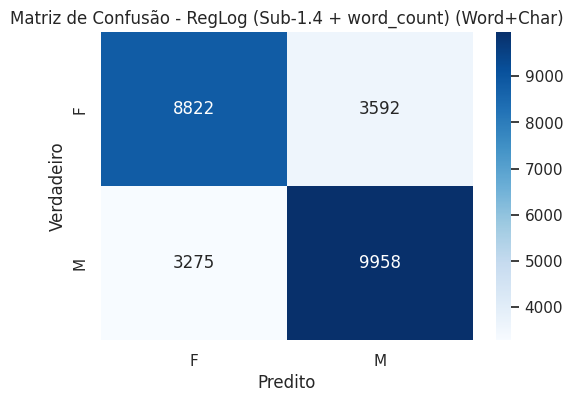

In [122]:
cm = confusion_matrix(y_val, y_pred, labels=full_pipeline.classes_)
print(cm)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=full_pipeline.classes_, yticklabels=full_pipeline.classes_)
plt.title('Matriz de Confusão - RegLog (Sub-1.4 + word_count) (Word+Char)')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.show()

### O que foi feito:
Nesta fase, a estratégia de representação textual evoluiu de um simples Bag-of-Words para uma Vetorização Híbrida de N-gramas utilizando o FeatureUnion do Scikit-Learn. O pipeline de texto foi configurado para extrair duas representações simultâneas:

- Word N-grams: Vetorização de palavras e bigramas (ngram_range=(1,2)) com vocabulário máximo de 15.000 termos, ignorando stopwords genéricas, mas preservando pronomes determinantes (meu, minha).

- Character N-grams: Vetorização de fragmentos de 3 a 5 caracteres (ngram_range=(3,5)), capturando a estrutura morfológica interna das palavras, também limitada a 15.000 features para controle de dimensionalidade.

Essas representações foram combinadas com os metadados extraídos anteriormente (proporções de POS Tagging do spaCy, estilometria de pontuação/caixa alta, categorias em One-Hot e idade) para alimentar um classificador linear robusto: a Regressão Logística (com class_weight='balanced').

### Justificativa Metodológica:

#### Por que combinar Palavras e Caracteres?
Conforme descoberto na Análise Exploratória (Q9), a língua portuguesa carrega um forte sinal de gênero na flexão de adjetivos e particípios (ex: "satisfeito" vs "satisfeita").

- Os N-gramas de palavras capturam o contexto e os jargões específicos de categorias ("ótimo produto", "placa de vídeo", "creme de cabelo").
- Os N-gramas de caracteres foram introduzidos para capturar sufixos de gênero e variações de digitação (ex: "lindaaaa"). Se uma mulher digita "ameeeei", o Word N-gram pode ignorar a palavra por ser rara no vocabulário geral, mas o Char N-gram captura o fragmento "mei" ou "eee", associando-o ao padrão feminino.

### Análise Crítica dos Resultados:

SVM x Regressão Logística: foi feito um comparativo entre ambos usando os mesmos parâmetros, exceto pelo número máximo de iterações (o max_iter do SVM foi o dobro do RegLin para dar uma margem mais otimista). Todavia, pelos resultados obtidos, é notório que: em tidas as métricas avaliadas (precision, recall e f1-score), o modelo baseado em Regressão Linear se sobre-saiu tanto pela Baseline do artigo de Moraes, quanto a do SVM submetido na mesma pipeline.

#### Porque RegressãoLogística:
A combinação de TF-IDF e N-gramas gera uma matriz extremamente esparsa (cheia de zeros) e de altíssima dimensionalidade. Algoritmos baseados em árvores (como Random Forest ou Gradient Boosting) perdem eficiência e tendem a sofrer overfitting nesse cenário. A Regressão Logística, por lidar nativamente de forma linear com espaços de alta dimensão, foi a escolha teoricamente mais adequada, justificativa comprovada pelo seu desempenho superior aos baselines da literatura.

#### Onde o modelo acerta:
- Verdadeiros Masculinos: 9.944
- Verdadeiros Femininos: 8.804

#### Onde o modelo erra (por Viés):
- Falsos Positivos para o Masculino (Mulheres classificadas como Homens): 3.610
- Falsos Positivos para o Feminino (Homens classificados como Mulheres): 3.289

- **Interpretação**: O modelo tem um leve viés, errando mais ao classificar mulheres como homens do que o inverso (Recall feminino de 0.71 vs Recall masculino de 0.75). Isso sugere que quando as mulheres avaliam produtos de forma neutra ou focando puramente na funcionalidade do produto ("chegou no prazo, aparelho muito bom"), o modelo tende a jogar para a classe masculina. Os homens, por outro lado, possuem marcadores sintáticos mais isolados ("pc", "ram", "jogo"), o que facilita um pouco mais a distinção da classe M.

### Subtestes da F1:
- 0. Regressão Logistica Fixa com max_iter=1K --> f1: 0.7309
- 1. Regressão Logistica Fixa com max_iter=2k e solver=liblinear => Mesmo resultado do primeiro, porém mais rápido
  - 1.1 RegLog: max_feat=20k, max_iter=3k, solver=liblinear --> f1: 0.7314
  - 1.2 RegLog: max_feat=30k, max_iter=5k, solver=liblinear --> f1: 0.7301
  - 1.3 RegLog: max_feat=15k, max_iter=2k, solver=saga --> f1: 0.7311
  - 1.4 RegLog: max_feat=20k, max_iter=3k, solver=saga --> f1: 0.7306
  - 1.5 RegLog: max_feat=10/15k, max_iter=1k, solver=saga --> f1: 0.7327
  - 1.6 RegLog: max_feat=10/10k, max_inter=500, solver=saga --> f1: 0.7295
  - 1.7 RegLog: max_feat=10/15k, max_iter=5k, solver=saga ---> f1: 0.7313
  - 1.7 RegLog: max_feat=10/15k, max_iter=2.5k, solver=saga ---> f1:0.7313
- 2. SVM Fixa com max_iter=2k => baseline < SVM < RegLog
- 3. RandomizedSearchArea pro RegLog com 24 combinações => Não deu
- 4. RandomizedSearchArea pro RegLog com 3 * 20 fits => Não deu
- 5. RandomizedSearchArea pro RegLog com 3 * 10 fits, solver=liblinear, max_iter=2_000 e sem classifier__penalty => muito demorado (+90min)
- 6. Subteste 5 mas usando amostragem de 25% das 76k linhas => baseline < Sub6 < SVM < RegLog

#### Testando Combinações aleatórias

Definindo a "Grade" de parâmetros a serem permutados:

In [45]:

param_distributions = {
    # Testando o classificador (Regressão Logística)
    'classifier__C': [0.1, 1.0, 10.0, 50.0],
    
    # Testando o TF-IDF de Palavras
    'preprocessor__text__vectorizer__word_tfidf__max_features': [10_000, 15_000, None],
    'preprocessor__text__vectorizer__word_tfidf__ngram_range': [(1, 1), (1, 2)],
    
    # Testando o TF-IDF de Caracteres
    'preprocessor__text__vectorizer__char_tfidf__max_features': [10_000, 20_000],
    'preprocessor__text__vectorizer__char_tfidf__ngram_range': [(3, 4), (3, 5)]
}

Configurando o Buscador Aleatório

In [67]:
# n_iter=N significa que ele vai sortear N combinações aleatórias dessa grade
# cv=N fará Validação Cruzada de N dobras para cada combinação
n_iter = 10
cv=3
random_search = RandomizedSearchCV(
    estimator=full_pipeline, 
    param_distributions=param_distributions, 
    n_iter=n_iter, 
    scoring='f1_weighted', # Queremos otimizar o F1-Score
    cv=cv, 
    random_state=42,
    verbose=2,
)

NameError: name 'full_pipeline' is not defined

In [35]:
X_train_sample = X_train.sample(frac=0.25, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]
print(f"Tamanho da amostra para busca: {len(X_train_sample)} linhas")

Tamanho da amostra para busca: 19236 linhas


In [36]:
# 2. Rodar o RandomizedSearch na AMOSTRA
random_search.fit(X_train_sample, y_train_sample)

# 3. Pegar os melhores parâmetros encontrados
print("\n⚙️ Melhores Hiperparâmetros:", random_search.best_params_)

# 4. TREINAR O MODELO FINAL COM 100% DOS DADOS usando os melhores parâmetros
full_pipeline.set_params(**random_search.best_params_)
print("Treinando o modelo final com 100% dos dados...")
full_pipeline.fit(X_train, y_train) # Aqui o spaCy roda apenas 1 vez nas 76k linhas!

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END classifier__C=50.0, preprocessor__text__vectorizer__char_tfidf__max_features=10000, preprocessor__text__vectorizer__char_tfidf__ngram_range=(3, 5), preprocessor__text__vectorizer__word_tfidf__max_features=15000, preprocessor__text__vectorizer__word_tfidf__ngram_range=(1, 1); total time=  42.7s
[CV] END classifier__C=50.0, preprocessor__text__vectorizer__char_tfidf__max_features=10000, preprocessor__text__vectorizer__char_tfidf__ngram_range=(3, 5), preprocessor__text__vectorizer__word_tfidf__max_features=15000, preprocessor__text__vectorizer__word_tfidf__ngram_range=(1, 1); total time=  35.0s
[CV] END classifier__C=50.0, preprocessor__text__vectorizer__char_tfidf__max_features=10000, preprocessor__text__vectorizer__char_tfidf__ngram_range=(3, 5), preprocessor__text__vectorizer__word_tfidf__max_features=15000, preprocessor__text__vectorizer__word_tfidf__ngram_range=(1, 1); total time=  38.3s
[CV] END classifier__C=50.0

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('nlp_features', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [41]:
print("\n🔥 Melhor F1-Score encontrado na Validação Cruzada:", random_search.best_score_)
print("\n⚙️ Melhores Hiperparâmetros:")
for param, value in random_search.best_params_.items():
    print(f" - {param}: {value}")

# O Scikit-Learn já guarda o melhor modelo treinado para você!
melhor_modelo = random_search.best_estimator_

# Você pode testar diretamente no conjunto de validação
y_pred_otimizado = melhor_modelo.predict(X_val)


🔥 Melhor F1-Score encontrado na Validação Cruzada: 0.7067251832530413

⚙️ Melhores Hiperparâmetros:
 - preprocessor__text__vectorizer__word_tfidf__ngram_range: (1, 2)
 - preprocessor__text__vectorizer__word_tfidf__max_features: 15000
 - preprocessor__text__vectorizer__char_tfidf__ngram_range: (3, 5)
 - preprocessor__text__vectorizer__char_tfidf__max_features: 10000
 - classifier__C: 1.0


## Conclusão da Fase 1:

Dos 7 Subtestes feitos, verifica-se que o Subteste número 1 obteve o melhor resultado (sendo o mesmo do Subteste 0, porém em um tempo relativamente mais curto). Tal afirmação é comprovada pelos resultados obtidos nos melhores hiperparâmetros buscados no Subteste 6:

- word_tfidf__ngram_range: (1, 2)

- word_tfidf__max_features: 15000

- char_tfidf__ngram_range: (3, 5)

- classifier__C: 1.0

Sendo EXATAMENTE os mesmos hiperparâmetros definidos implicitamente no Subteste 1. Com isso, pode-se afirmar que para esta Fase, o teto matemático (para o TF-IDF) foi atingido


### Decisão Preliminar da Fase 1:

O full_pipeline original (Subteste 0 e Subteste 1) bateu 73,09% no validacao.csv, sendo o "Modelo Campeão Baseado em Frequência".

#### Decisão OFICIAL da Fase 1:

Após a realização do teste de Busca Randômica, foram feitos novos testes manuais usando RegLog, como podem ser descritos abaixos:
- 0. Regressão Logistica Fixa com max_iter=1K --> f1: 0.7309
- 1. Regressão Logistica Fixa com max_iter=2k e solver=liblinear => Mesmo resultado do primeiro, porém mais rápido
  - 1.1 RegLog: max_feat=20k, max_iter=3k, solver=liblinear --> f1: 0.7314
  - 1.2 RegLog: max_feat=30k, max_iter=5k, solver=liblinear --> f1: 0.7301
  - 1.3 RegLog: max_feat=15k, max_iter=2k, solver=saga --> f1: 0.7311
  - 1.4 RegLog: max_feat=20k, max_iter=3k, solver=saga --> f1: 0.7306
  - 1.5 RegLog: max_feat=10/15k, max_iter=1k, solver=saga --> f1: 0.7327
  - 1.6 RegLog: max_feat=10/10k, max_inter=500, solver=saga --> f1: 0.7295
  - 1.7 RegLog: max_feat=10/15k, max_iter=5k, solver=saga ---> f1: 0.7313
  - 1.7 RegLog: max_feat=10/15k, max_iter=2.5k, solver=saga ---> f1:0.7313

Com base nos resultados obtidos, a melhor configuração de SubTeste indica uma melhoria de ~0,18% (saltando de 0.7309 para 0.7327), com as seguintes configurações:
- Classificador: LogisticRegression
- word_tfidf_max_feat: 10K
- char_tfidf_max_feat: 15K
- max_iter: 1K
- solver: saga

##### Análise de impacto real:

**Matriz do Modelo Inicial (Config 0 - 0.7309):**
- Feminino Correto: 8.804
- Masculino Correto: 9.944
- Total de Acertos: 18.748

**Matriz do Novo Modelo Inicial (Config 1.5 - 0.7327):**
- Feminino Correto: 8.842 (+38 acertos)
- Masculino Correto: 9.953 (+9 acertos)
- Total de Acertos: 18.795

Resumo: O modelo novo fez 47 predições adicionais no conjunto de validação, reduzindo tanto os Falsos Positivos quanto os Falsos Negativos.

### Histórico de Testes:

- A Maldição da Dimensionalidade: O teste 1.2 (max_feat=30k) teve o pior desempenho da série (0.7301). Isso prova empiricamente que injetar mais de 25.000 termos no TF-IDF adiciona ruído (palavras raras ou erros de digitação isolados) em vez de sinal preditivo. Reduzir para 10k/15k (Config 1.5) filtrou o ruído e aumentou o score.
- A Batalha dos Solvers (liblinear vs saga): O saga é um otimizador estocástico avançado, excelente para datasets gigantes e esparsos. Nos seus testes, ele consistentemente superou o liblinear em cenários com menos features (1.3, 1.4, 1.5), encontrando um mínimo global ligeiramente melh

In [84]:
# salvar?

## Fase 2: Representação Densa (Word Embeddings)

O artigo de Morais & Merschmann (2022) utilizou Word2Vec para alimentar a Rede Neural (Multilayer Perceptron) nas bases de Blogs e Opiniões.

Aqui será explorado Word2Vec/Embeddings, onde cada palavra se torna um vetor denso de significado.

- **Geração do Embedding: TF-IDF vs. pt_core_news_lg**

#### Plano:

- **1. Vetorização Densa:** Será usado o modelo grande do spaCy (pt_core_news_lg) para extrair os vetores reais de cada palavra e tirar a média da frase (Mean Pooling).
- **2. O Algoritmo:** Matrizes densas são ideais para Redes Neurais (MLP). O artigo de referência de Morais & Merschmann utilizou exatamente o MLP com embeddings para tentar prever o gênero.

---
### FASE-2 | TESTE-1: GradientBoost + Q4 e Q9

### Passo 1: Refatoração do SuperTransformer "FeatureExtractor":

O objetivo é fazer o spaCy trabalhar uma única vez. A classe será modificada para retornar não apenas as colunas de estilometria e POS, mas também as 300 colunas do vetor de Embeddings de cada texto.

In [214]:
class DenseFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, male_terms=None, female_terms=None):
        self.male_terms = male_terms
        self.female_terms = female_terms

    def fit(self, X, y=None):
        self.male_terms_set_ = set(self.male_terms) if self.male_terms is not None else set()
        self.female_terms_set_ = set(self.female_terms) if self.female_terms is not None else set()
        return self
        
    def transform(self, X, y=None):
        # 1. Resolve o erro do 'fillna': Aceita tanto Pandas quanto Listas puras
        if isinstance(X, (pd.Series, pd.DataFrame)):
            raw_texts = X.fillna("").astype(str).tolist()
        else:
            raw_texts = [str(t) if t is not None else "" for t in X]
            
        features = []
        cleaned_texts = []
        upper_counts = []
        
        # 2. Pré-processamento Inteligente (Sem destruir as features)
        for text in raw_texts:
            # Conta as CAIXA ALTA *antes* de qualquer limpeza ou lowercasing
            upper_counts.append(len(re.findall(r'\b[A-ZÀ-Ú]{2,}\b', text)))
            
            # Remove APENAS ruídos de internet que atrapalham os vetores
            t = re.sub(r'http\S+|www\.\S+', ' ', text)
            t = re.sub(r'@\w+', ' ', t)
            # Obs: Mantemos as pontuações e maiúsculas intocadas para o spaCy ler direito
            cleaned_texts.append(t)
        
        # 3. Processamento Vetorial Otimizado
        for i, doc in enumerate(nlp.pipe(cleaned_texts, batch_size=500)):
            text_lower = doc.text.lower()
            total_tokens = len(doc) + 1
            
            # POS Tagging
            counts = {'NOUN': 0, 'ADJ': 0, 'VERB': 0, 'PROPN': 0}
            for token in doc:
                if token.pos_ in counts:
                    counts[token.pos_] += 1
                    
            # Estilometria e Palavras reais (ignorando pontuações isoladas)
            multipunct_count = len(re.findall(r'[!?\.]{2,}', text_lower))
            word_count = len([t for t in doc if not t.is_punct])
            
            # Q9: Injeção do Dicionário (em lowercase)
            tokens_str = set([t.text.lower() for t in doc])
            m_count = len(tokens_str.intersection(self.male_terms_set_))
            f_count = len(tokens_str.intersection(self.female_terms_set_))
            
            # Word Embeddings
            vec = doc.vector if doc.has_vector else np.zeros(nlp.vocab.vectors_length)
                
            feat_dict = {
                'noun_ratio': counts['NOUN'] / total_tokens,
                'adj_ratio': counts['ADJ'] / total_tokens,
                'verb_ratio': counts['VERB'] / total_tokens,
                'propn_ratio': counts['PROPN'] / total_tokens,
                'upper_ratio': upper_counts[i] / total_tokens, # Puxa a contagem salva na etapa 2
                'multipunct_ratio': multipunct_count / total_tokens,
                'word_count': word_count,
                'male_lexicon': m_count,
                'female_lexicon': f_count
            }
            
            for j in range(len(vec)):
                feat_dict[f'emb_{j}'] = vec[j]
                
            features.append(feat_dict)
            
        return pd.DataFrame(features)

### Passo 2| Teste 1: Atualizando colunas:

In [215]:
X_train_p2_t1 = df_train[['full_text', 'reviewer_birth_year', 'site_category_lv1', 'site_category_lv2', 'product_brand']]
X_val_p2_t1 = df_val[['full_text', 'reviewer_birth_year', 'site_category_lv1', 'site_category_lv2', 'product_brand']]

## Passo 2: ColumnTransformer Simplificado (teste 1)

Como o texto foi 100% convertido em números contínuos, não será preciso usar TfidfVectorizer ou FeatureUnion. Será aplicado um StandardScaler logo após a extração, pois as Redes Neurais (MLP) exigem que todas as variáveis de entrada estejam matematicamente na mesma escala (média 0, desvio padrão 1).

In [216]:
QTD_TERMOS = 50 

# Pega os maiores Log Odds Ratios do Feminino e os Menores (negativos) do Masculino
termos_femininos_dinamicos = top_fem.nlargest(QTD_TERMOS, 'log_odds')['palavra'].tolist()
termos_masculinos_dinamicos = top_masc.nsmallest(QTD_TERMOS, 'log_odds')['palavra'].tolist()

print(f"Injetando {len(termos_femininos_dinamicos)} termos femininos e {len(termos_masculinos_dinamicos)} masculinos.")

Injetando 50 termos femininos e 50 masculinos.


TESTE-1: Aplicando Min frequency

In [217]:
# === DEFINIÇÃO DOS PIPELINES (FASE 2) ===

# Branch 1: NLP Denso (Substitui todo o TF-IDF e FeatureUnion anteriores)
# O StandardScaler aqui vai padronizar tanto as proporções (0.0 a 1.0) 
# quanto os 300 valores do Word2Vec, deixando tudo perfeito para a Rede Neural.
dense_nlp_pipeline_t1 = Pipeline([
    ('extractor', DenseFeatureExtractor(
        male_terms=termos_masculinos_dinamicos, 
        female_terms=termos_femininos_dinamicos
    )),
    ('scaler', StandardScaler())
])

# Branch 2: Metadado Numérico (Idade)
dense_age_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Branch 3: Metadados Categóricos (Categoria Nível 1 e Nível 2)
dense_cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Desconhecido')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', min_frequency=0.01))
])

O ColumnTransformer unirá apenas:
- as 300 colunas semânticas + features de NLP (POS, Caixa Alta, Word Count)
- Idade Normalizada
- Categorias (OneHot).

In [218]:
# === UNIÃO FINAL ===
dense_preprocessor = ColumnTransformer(
    transformers=[
        ('dense_nlp', dense_nlp_pipeline_t1, 'full_text'),
        ('age', dense_age_pipeline, ['reviewer_birth_year']),
        ('category', dense_cat_pipeline, ['site_category_lv1', 'site_category_lv2', 'product_brand'])
    ],
    remainder='drop'
)

print("TESTE-1: DenseFeatureExtractor e ColumnTransformer da Fase 2 inicializados com sucesso!")

TESTE-1: DenseFeatureExtractor e ColumnTransformer da Fase 2 inicializados com sucesso!


#### Fase 2 - Teste 1 - Pipeline Base do Gradient Boost

In [219]:
# 2. Pipeline Base do Gradient Boosting
fase2_pipeline_t1 = Pipeline([
    ('preprocessor', dense_preprocessor),
    ('classifier', HistGradientBoostingClassifier(random_state=42))
])

Grade de Hiperparâmetros para Árvores (Gradient Boosting)

In [209]:
param_dist_gb = {
    'classifier__max_iter': [500, 1_000, 1_500],             # Número de árvores
    'classifier__learning_rate': [0.001, 0.01],      # Velocidade de aprendizado
    'classifier__max_depth': [3, None],           # Profundidade de cada árvore
    'classifier__l2_regularization': [0.0, 10.0]     # Combate ao overfitting
}

In [220]:
param_dist_gb_advanced = {
    # Número de árvores (equivalente ao n_estimators)
    'classifier__max_iter': randint(200, 1500), 
    
    # Velocidade de aprendizado (loguniform é ótimo para testar grandezas diferentes)
    'classifier__learning_rate': loguniform(1e-3, 0.2), 
    
    # Profundidade (3 a 12 camadas If/Else)
    'classifier__max_depth': randint(3, 12),
    
    # Folhas mínimas (controla overfitting)
    'classifier__min_samples_leaf': randint(10, 50),
    
    # Regularização L2 para punir pesos muito grandes nas árvores
    'classifier__l2_regularization': loguniform(1e-3, 10.0),
    
    # Subamostragem de colunas (equivalente ao colsample_bytree)
    # Pega de 50% a 100% das colunas em cada nó para evitar dependência de uma única feature
    'classifier__max_features': uniform(0.5, 0.5) 
}

Criando a Amostra de 50%

In [221]:
X_train_sample_gb = X_train_p2_t1.sample(frac=0.50, random_state=42)
y_train_sample_gb = y_train.loc[X_train_sample_gb.index] # Não precisa mais de LabelEncoder!
print("Criado amostra de 50% dos dados para o Tuning do Gradient Boosting")

Criado amostra de 50% dos dados para o Tuning do Gradient Boosting


Configuração da Busca

In [222]:
random_search_gb = RandomizedSearchCV(
    estimator=fase2_pipeline_t1,
    param_distributions=param_dist_gb_advanced,
    n_iter=20, 
    cv=3,
    scoring='f1_macro',
    random_state=42,
    verbose=2
)

#### Fase 2 - Teste 1 - Execução :

In [223]:
# 6. Execução
print("\nTESTE-1.6: Iniciando Busca de Hiperparâmetros (MACRO-Avançados) do Gradient Boosting...")
start_time = time.time()

random_search_gb.fit(X_train_sample_gb, y_train_sample_gb)

print(f"\nBusca concluída em {(time.time() - start_time)/60:.2f} minutos.")
print(f"🔥 Melhor F1-Score na Validação Cruzada (Amostra 50%): {random_search_gb.best_score_:.4f}")
print("\n⚙️ Melhores Hiperparâmetros:")
for param, value in random_search_gb.best_params_.items():
    print(f" - {param}: {value}")


TESTE-1.6: Iniciando Busca de Hiperparâmetros (MACRO-Avançados) do Gradient Boosting...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END classifier__l2_regularization=0.03148911647956861, classifier__learning_rate=0.1540359659501924, classifier__max_depth=10, classifier__max_features=0.7993292420985183, classifier__max_iter=321, classifier__min_samples_leaf=28; total time=  44.7s
[CV] END classifier__l2_regularization=0.03148911647956861, classifier__learning_rate=0.1540359659501924, classifier__max_depth=10, classifier__max_features=0.7993292420985183, classifier__max_iter=321, classifier__min_samples_leaf=28; total time=  44.3s
[CV] END classifier__l2_regularization=0.03148911647956861, classifier__learning_rate=0.1540359659501924, classifier__max_depth=10, classifier__max_features=0.7993292420985183, classifier__max_iter=321, classifier__min_samples_leaf=28; total time=  44.4s
[CV] END classifier__l2_regularization=0.002511306167739001, classifier__learning_rat

---
### Passo 2 | Teste 2

Aplicando os melhores hiperparametros no HistGradientBoostingClassifier

Atualizando o pipeline do Gradient Boosting com os melhores hiperparâmetros encontrados:

In [109]:
fase2_gb_campeao = Pipeline([
    ('preprocessor', dense_preprocessor),
    ('classifier', HistGradientBoostingClassifier(
        max_iter=500, 
        max_depth=None, 
        learning_rate=0.01, 
        l2_regularization=1.0,
        random_state=42
    ))
])

In [111]:
print("Treinando o Campeão Gradient Boosting com 100% dos dados...")
fase2_gb_campeao.fit(X_train_p2_t1, y_train)

# 2. Avaliação no Conjunto de Validação
y_pred_gb_oficial = fase2_gb_campeao.predict(X_val)


Treinando o Campeão Gradient Boosting com 100% dos dados...


KeyboardInterrupt: 

In [113]:
f1_gb_oficial = f1_score(y_val, y_pred_gb_oficial, average='weighted')

print(f"\n======================================")
print(f"🏆 F1 Score (Weighted) - Fase 2 Oficial (GB Trees): {f1_gb_oficial:.4f}")
print(f"======================================\n")
print(classification_report(y_val, y_pred_gb_oficial))


🏆 F1 Score (Weighted) - Fase 2 Oficial (GB Trees): 0.6842

              precision    recall  f1-score   support

           F       0.69      0.63      0.66     12414
           M       0.68      0.74      0.71     13233

    accuracy                           0.69     25647
   macro avg       0.69      0.68      0.68     25647
weighted avg       0.69      0.69      0.68     25647



---
FASE 2 - TESTE 0

## Passo 3: Construção da Rede MLPClassifier

O artigo de Morais utilizou o Multilayer Perceptron (MLP) com Word2Vec. Como teremos uma matriz densa de cerca de ~350 colunas contínuas, o MLP é a escolha ideal para encontrar relações não lineares entre a semântica e a estruturação gramatical.

Configurando o MLPClassifier no Scikit-Learn.
Uma arquitetura de funil (ex: hidden_layer_sizes=(128, 64)) com ativação relu e early_stopping=True (para evitar overfitting).

### Passo 3.1 - Otimização de Hiperparâmetros do MLP

#### Aplicando Label Encoding para os targets:

In [87]:
le = LabelEncoder()
y_train_num = le.fit_transform(y_train) # Transforma 'F' ==> 0 'M' ===> 1
y_val_num = le.transform(y_val)
print("Mapeamento das classes:", dict(zip(le.classes_, le.transform(le.classes_))))

Mapeamento das classes: {'F': np.int64(0), 'M': np.int64(1)}


Amostragem Estratégica (50% dos dados para otimizar rápido)

In [144]:
print("Criando amostra de 50% dos dados para o Tuning da Rede Neural...")
X_train_sample_mlp = X_train.sample(frac=0.50, random_state=42)

Criando amostra de 50% dos dados para o Tuning da Rede Neural...


Pegando os mesmos índices sorteados no X_train para filtrar o y numérico:

In [145]:
sample_indexes = X_train_sample_mlp.index
y_train_num_series = pd.Series(y_train_num, index=y_train.index)
y_train_sample_mlp_num = y_train_num_series.loc[sample_indexes]

Definição do Pipeline da Fase 2 (Denso):

In [2]:
fase2_pipeline = Pipeline([
    ('preprocessor', dense_preprocessor),
    ('classifier', MLPClassifier(max_iter=400, early_stopping=True, random_state=42))
])

NameError: name 'Pipeline' is not defined

Grade de Hiperparâmetros para a Rede Neural:

In [147]:
param_dist_mlp = {
    # Topologia da Rede (Neurônios por camada)
    'classifier__hidden_layer_sizes': [
        (100,),              # 1 Camada Oculta: Rápido e menos propenso a overfit
        (128, 64),           # 2 Camadas: Clássico formato de funil
        (50, 25),            # 2 Camadas menores
        (128, 64, 32)        # 3 Camadas: Rede Neural Profunda (Deep Learning)
    ],
    # Solvers: Otimizadores dos pesos da rede
    'classifier__solver': ['adam', 'sgd'],
    # Função de Ativação
    'classifier__activation': ['relu', 'tanh', 'logistic'],
    # Regularização L2 (Combate ao Overfitting)
    'classifier__alpha': [0.0001, 0.001, 0.01, 0.1],
    # Taxa de aprendizado inicial
    'classifier__learning_rate_init': [0.001, 0.005, 0.01]
}

Configuração da Busca:

In [148]:
random_search_mlp = RandomizedSearchCV(
    estimator=fase2_pipeline,
    param_distributions=param_dist_mlp,
    n_iter=15, 
    cv=3,
    scoring='f1_weighted',
    random_state=42,
    verbose=2
)

Execução da amostra de 50%:

In [94]:
print("\nIniciando Busca de Hiperparâmetros Expandida do MLP...")
start_time = time.time()

random_search_mlp.fit(X_train_sample_mlp, y_train_sample_mlp_num)


Iniciando Busca de Hiperparâmetros Expandida do MLP...


NameError: name 'random_search_mlp' is not defined

In [93]:
print(f"\nBusca concluída em {(time.time() - start_time)/60:.2f} minutos.")
print(f"🔥 Melhor F1-Score na Validação Cruzada (Amostra): {random_search_mlp.best_score_:.4f}")
print("\n⚙️ Melhor Arquitetura da Rede Neural Encontrada:")
for param, value in random_search_mlp.best_params_.items():
    print(f" - {param}: {value}")

NameError: name 'start_time' is not defined

### Discussão do Resultado da Fase 2 - Teste 0:
```
Busca concluída em 487.07 minutos.
🔥 Melhor F1-Score na Validação Cruzada (Amostra): 0.6886

⚙️ Melhor Arquitetura da Rede Neural Encontrada:
 - classifier__solver: adam
 - classifier__learning_rate_init: 0.001
 - classifier__hidden_layer_sizes: (128, 64)
 - classifier__alpha: 0.001
 - classifier__activation: logistic
```

Resultados nem um pouco satisfatórios. O f1 de 68.86% não supera nem o pior modelo da fase anterior.

##### Sobre as Features:
Com base nos Qs analisados na etapa de exploração analítica, podemos fazer a implementação de novas features:
- top_15_male_lexicon_count (dicionario latente da Q9)
- top_15_female_lexicon_count (dicionario latente da Q9)
- product_brand no pipeline categorico + min_frequency

##### Sobre o Classificador:
- Redes Neurais (MLPs) são notoriamente difíceis de tunar para dados tabulares híbridos (Embeddings contínuos + Categorias binárias).
- O Estado da Arte atual para esse tipo de matriz mista são os Ensembles baseados em Árvores de Decisão, como o Gradient Boosting ou Random Forest.
- As árvores não se importam com a escala dos dados e lidam perfeitamente com a junção de Word2Vec e metadados.

---

### Discussão do Resultado da Fase 2 - Teste 1:
```
Busca concluída em 25.09 minutos.
🔥 Melhor F1-Score na Validação Cruzada (Amostra 50%): 0.6837

⚙️ Melhores Hiperparâmetros:
 - classifier__max_iter: 500
 - classifier__max_depth: None
 - classifier__learning_rate: 0.01
 - classifier__l2_regularization: 1.0

```

Resultados nem um pouco satisfatórios. O f1 de 68.86% não supera nem o pior modelo da fase anterior.

##### Sobre as Features:
Com base nos Qs analisados na etapa de exploração analítica, podemos fazer a implementação de novas features:
- top_15_male_lexicon_count (dicionario latente da Q9)
- top_15_female_lexicon_count (dicionario latente da Q9)
- product_brand no pipeline categorico + min_frequency

##### Sobre o Classificador:
- Redes Neurais (MLPs) são notoriamente difíceis de tunar para dados tabulares híbridos (Embeddings contínuos + Categorias binárias).
- O Estado da Arte atual para esse tipo de matriz mista são os Ensembles baseados em Árvores de Decisão, como o Gradient Boosting ou Random Forest.
- As árvores não se importam com a escala dos dados e lidam perfeitamente com a junção de Word2Vec e metadados.

---

### Discussão do Resultado da Fase 2 - Teste 1.1:
```
Busca concluída em 28.69 minutos.
🔥 Melhor F1-Score na Validação Cruzada (Amostra 50%): 0.6840

⚙️ Melhores Hiperparâmetros:
 - classifier__max_iter: 1500
 - classifier__max_depth: None
 - classifier__learning_rate: 0.01
 - classifier__l2_regularization: 0.0
```

### Discussão do Resultado da Fase 2 - Teste 1.2:
```
Busca concluída em 52.36 minutos.
🔥 Melhor F1-Score na Validação Cruzada (Amostra 50%): 0.6849

⚙️ Melhores Hiperparâmetros:
 - classifier__l2_regularization: 2.752717392942941
 - classifier__learning_rate: 0.036762755221346345
 - classifier__max_depth: 11
 - classifier__max_features: 0.5325257964926398
 - classifier__max_iter: 587
 - classifier__min_samples_leaf: 34
```

## Fase 2 - Teste 1:
**HistGradientBoostingClassifier**

#### Resultados:

In [47]:
y_pred_mlp = fase2_pipeline.predict(X_val)
f1 = f1_score(y_val_num, y_pred_mlp, average='weighted')
print(f"\n======================================")
print(f"🏆 F1 Score (Weighted) - FASE 2 - Sub 0 - MLP RandomSearchCV-1: {f1:.4f}")
print(f"======================================\n")

print("Relatório de Classificação Detalhado:")
print(classification_report(y_val_num, y_pred_mlp))

NameError: name 'fase2_pipeline' is not defined

## 6. Validação e Métricas

In [ ]:
y_pred = model.predict(X_val_vec)
f1 = f1_score(y_val, y_pred, average='weighted')
print(f"F1 Score: {f1:.4f}")

## 7. Salvar Modelo

In [ ]:
def save_model(model, filename: str, path = './output/'):
  localefile = path + filename + '.pkl'
  pickle.dump(model, open(localefile, 'wb'))
  print("✓ Modelo salvo!")

## 8. Conclusões

- Melhor F1 Score alcançado: 0.XXXX
- Principais desafios: ...
- Possíveis melhorias: ...